**17.2. Dr.ML - Disease Prediction Suite**

**17.2.1. Diabetes Prediction using ML**

Dataset: `diabetes.csv`

**1. Setup**

In [4]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost joblib

Note: you may need to restart the kernel to use updated packages.


In [5]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score,
)

In [6]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42
CSV_PATH = r"C:\Users\manor\OneDrive\Desktop\dr-ml-multi-desease-predictor\dataset\diabetes.csv"
TARGET_COL="Outcome"

**2. Load Data**

In [7]:
df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


**3. Exploratory Data Analysis**

**Target:**
- 0 - non-diabetic
- 1 - diabetic

In [8]:
# basic overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**8 Numerical columns and no categorical columns**

In [9]:
# missing values
df.isna().sum().sort_values()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Pregnancies
1    135
0    111
2    103
3     75
4     68
5     57
6     50
7     45
8     38
9     28
Name: count, dtype: int64
Glucose
99     17
100    17
111    14
125    14
129    14
106    14
102    13
105    13
112    13
95     13
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
64    43
80    40
76    39
60    37
0     35
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
Name: count, dtype: int64
Insulin
0      374
105     11
130      9
140      9
120      8
94       7
180      7
100      7
110      6
115      6
Name: count, dtype: int64
BMI
32.000    13
31.600    12
31.200    12
0.000     11
32.400    10
33.300    10
32.900     9
30.100     9
30.800     9
32.800     9
Name: count, dtype: int64
DiabetesPedigreeFunction
0.258    6
0.254    6
0.207    5
0.261    5
0.259    5
0.238    5
0.268    5
0.270    4
0.263    4
0.304    4
Name: count, dtype: int64
Age

>**Inference:** Some columns have missing values encoded as missing values

In [11]:
# identify columns with zero values
zero_summary = (
    df.eq(0)
      .sum()
      .to_frame(name="zero_count")
      .assign(zero_percentage=lambda x: (x["zero_count"] / len(df)) * 100)
)

zero_summary

,zero_count,zero_percentage
Pregnancies,111,14.453
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,500,65.104


>**NOTE:** In this dataset, Pregnancies can legitimately have a value of 0, while 0 in Glucose, BloodPressure, SkinThickness, Insulin, and BMI is physiologically invalid and therefore represents missing data. These values need to be imputed with mean/median value

In [12]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [13]:
# target distribution
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
--------------------------------------------------
Outcome
0   65.104
1   34.896
Name: proportion, dtype: float64


>NOTE: There is some imbalance, so we will pay attention to recall/F1 and use class weighting.

In [14]:
# imbalance ratio
n_diab = (df[TARGET_COL] == 1).sum()
n_non_diab = (df[TARGET_COL] == 0).sum()
print("\nImbalance ratio (Non-diabetic : Daibetic) =", round(n_non_diab / max(n_diab, 1), 2))


Imbalance ratio (Non-diabetic : Daibetic) = 1.87


In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


**Data Visualization**

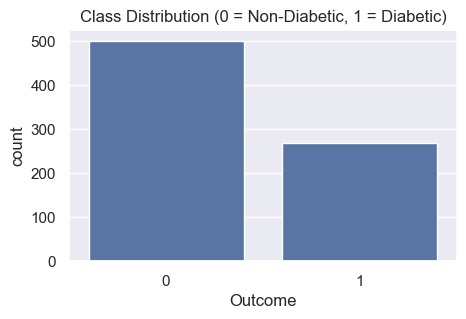

In [16]:
# visualize class imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

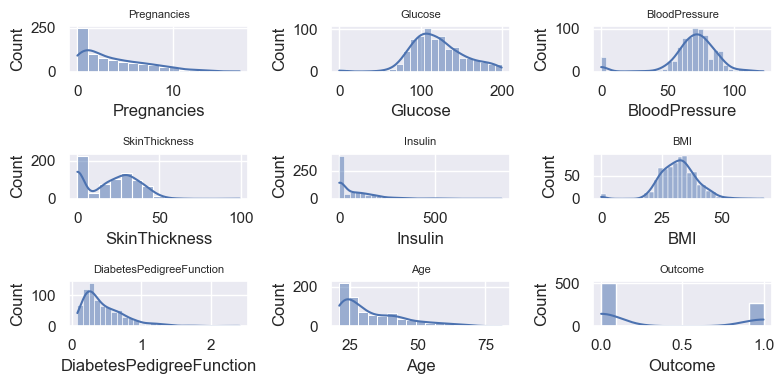

In [17]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

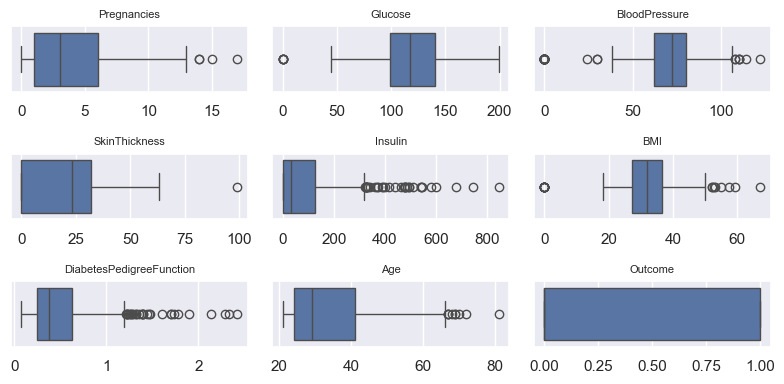

In [18]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

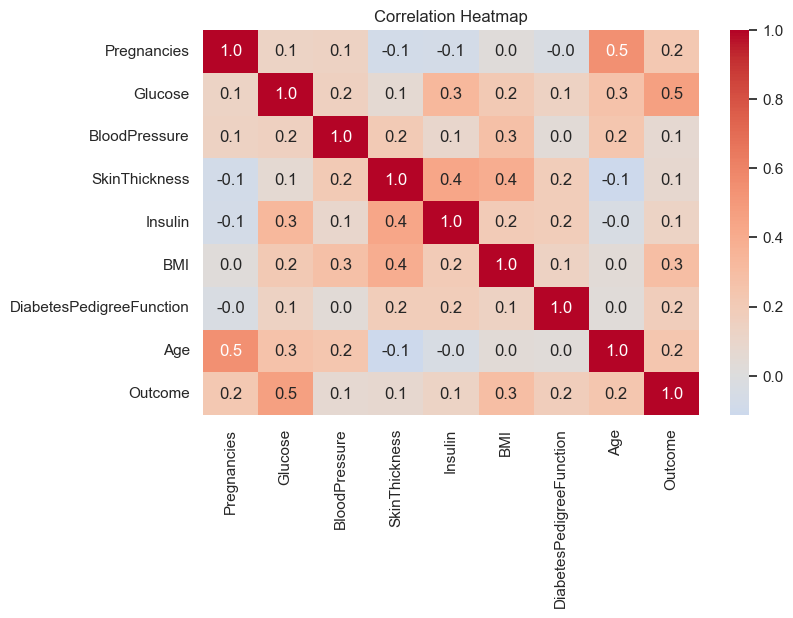

In [19]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Not high correlation**

**4. Data Preprocessing**

In [20]:
# separate data into features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [21]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [22]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (768, 8)
Train Dataset size (614, 8)
Test Dataset size (154, 8)


**Preprocessing Pipeline**

In [23]:
# 0 -> NAN for selected columns; NAN -> median imputation
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# transformer to replace 0 -> NaN only for selected columns
# zero_to_nan = FunctionTransformer(
#     lambda X: X.assign(**{col: X[col].replace(0, np.nan) for col in zero_as_missing_cols}),
#     validate=False
# )

def replace_zeros_with_nan_df(X, cols):
    """
    Replace 0 -> NaN for selected columns in a pandas DataFrame.
    Returns a NEW DataFrame (safe for sklearn pipelines).
    """
    X = X.copy()
    for col in cols:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
    return X

zero_to_nan = FunctionTransformer(
    replace_zeros_with_nan_df,
    kw_args={"cols": zero_as_missing_cols},
    validate=False
)

numerical_transformer = Pipeline(steps=[
    ("zero_to_nan", zero_to_nan),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features)
    ]
)

**5. Baseline Model - Logistic Regression**

In [24]:
# baseline model with preprocessing
baseline_lr = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression())
    ]
)

In [25]:
# training the pipeline
baseline_lr.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
# reusable evaluation function
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

    print("-"*40)

    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("-"*40)

    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

In [27]:
evaluate_classifier(
    model=baseline_lr,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Baseline Logistic Regression"
)

Baseline Logistic Regression - Train Accuracy: 79.64%
Baseline Logistic Regression - Test Accuracy: 70.78%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



**Low performance on class 1. Average Overall Score**

**6. Model Selection and Optimization**

In [28]:
# scale_pos_weight = (# negative samples) / (# positive samples)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1.8691588785046729


In [29]:
# models to try
models = {
    "LogisticRegression": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", LogisticRegression(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                max_iter=1000
            ))
        ]
    ),
    "SVC": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", SVC(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "RandomForest": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    ),
    "XGBClassifier": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
            ))

        ]
    )
}

In [30]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [31]:
for name, model_pipeline in models.items():

    recall_scores = []
    f1_scores = []

    for tr_idx, te_idx in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        model_pipeline.fit(X_tr, y_tr)
        pred = model_pipeline.predict(X_te)

        recall_scores.append(round(recall_score(y_te, pred), 2))
        f1_scores.append(round(f1_score(y_te, pred), 2))

    print("Model name:", name)
    print("Recall values:", recall_scores)
    print("F1 scores:", f1_scores)
    print("\nCV Recall mean:", round(float(np.mean(recall_scores)), 4))
    print("CV F1 Score mean:", round(float(np.mean(f1_scores)), 4))
    print("-"*50)

# cross validation is a more reliable validation technique

Model name: LogisticRegression
Recall values: [0.7, 0.74, 0.63, 0.72, 0.71]
F1 scores: [0.69, 0.67, 0.65, 0.68, 0.67]

CV Recall mean: 0.7
CV F1 Score mean: 0.672
--------------------------------------------------
Model name: SVC
Recall values: [0.77, 0.84, 0.67, 0.77, 0.76]
F1 scores: [0.74, 0.69, 0.69, 0.67, 0.66]

CV Recall mean: 0.762
CV F1 Score mean: 0.69
--------------------------------------------------
Model name: RandomForest
Recall values: [0.58, 0.58, 0.67, 0.58, 0.52]
F1 scores: [0.65, 0.62, 0.72, 0.6, 0.59]

CV Recall mean: 0.586
CV F1 Score mean: 0.636
--------------------------------------------------
Model name: XGBClassifier
Recall values: [0.58, 0.67, 0.63, 0.65, 0.62]
F1 scores: [0.62, 0.66, 0.64, 0.58, 0.59]

CV Recall mean: 0.63
CV F1 Score mean: 0.618
--------------------------------------------------


**NOTE: SVC (Support Vector Classifier) has better performance**

**Hyperparameter Tuning**

In [32]:
svc_opt = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
])

In [33]:
# param combinations
param_grid_svc = {
    "model__C": [0.1, 1, 10, 100, 1000],
    "model__gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

In [34]:
# grid search
grid_search = GridSearchCV(
    estimator=svc_opt,
    param_grid=param_grid_svc,
    scoring="f1",
    cv=cv,
    verbose=True,
    n_jobs=-1
)

In [35]:
# performing gridsearchcv
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': [0.001, 0.01, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [36]:
print("Hyperparameter Tuning result:")
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Hyperparameter Tuning result:
Best params: {'model__C': 1, 'model__gamma': 'scale'}
Best score: 0.6901634795182808


**7. Retrain with best params**

In [37]:
svc_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVC(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            C=1,
            gamma="scale"
        ))
    ]
)

In [38]:
# train the best pipeline
svc_best.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**8. Model Evaluation**

In [39]:
evaluate_classifier(
    model=svc_best,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Best SVC"
)

Best SVC - Train Accuracy: 82.25%
Best SVC - Test Accuracy: 72.73%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       400
           1       0.70      0.85      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.83       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



**9. Build a predictive system**

In [40]:
def predict_diabetes(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = svc_best.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Diabetic 🔴")
    else:
        print("Diagnosis - Non-Diabetic 🟢")


In [41]:
y_test[y_test==1].head()

630    1
387    1
408    1
78     1
678    1
Name: Outcome, dtype: int64

In [42]:
y_test[y_test==0].head()

44     0
672    0
700    0
81     0
389    0
Name: Outcome, dtype: int64

In [43]:
# sample unknown data point - access from test data index
test_1 = X_test.loc[630].tolist()
print(test_1)

[7.0, 114.0, 64.0, 0.0, 0.0, 27.4, 0.732, 34.0]


In [44]:
predict_diabetes(test_1)

Model prediction: [1]
Diagnosis - Diabetic 🔴


In [45]:
# sample unknown data point - access from test data index
test_2 = X_test.loc[700].tolist()
print(test_2)

[2.0, 122.0, 76.0, 27.0, 200.0, 35.9, 0.483, 26.0]


In [46]:
predict_diabetes(test_2)

Model prediction: [0]
Diagnosis - Non-Diabetic 🟢


>**Important Note:** This is a strong and realistic performance for this dataset. Even with correct preprocessing, cross-validation, and model tuning, some predictions will still be wrong. No model can achieve 100% accuracy on this problem because the dataset itself has overlapping patterns and noise, which creates a natural performance ceiling. While further improvements are possible through advanced techniques, this result is a solid and trustworthy stopping point for our current approach.
